# OpenAI-compatible provider capability experiment

```{exp} OpenAI-compatible provider capability experiment
:id: EXP_0004
:hide:
:experiment_date: 2026-09-02
:informs: ADR_0001, ADR_0002, TREQ_OPENAI_ADAPTER_BOUNDARY

**Question.** Can a generic OpenAI-compatible endpoint support the llm-router provider surface across text, retries, token logprobs, structured image input, and tool calling?

**Conclusion.** The captured run exercises the complete OpenAI-compatible experiment surface in one self-contained capsule and records the protocol behavior that informs the adapter boundary.
```

## Question

Can a generic OpenAI-compatible endpoint support the llm-router provider surface across text, retries, token logprobs, structured image input, and tool calling?

### Capability snapshot

Each capability below is captured in one linear live run. The sections show the exact input, the provider pipeline that ran, and the observed output.

| Capability | Live input / check |
| --- | --- |
| Async text generation | `Reply with only OK.` |
| Provider retry behavior | `Reply with only OK.` |
| Token logprobs | `What is the meaning of life? Explain in one sentence.` |
| Image input with structured output | file `test_image.png` |
| Multi-round tool calling | `You have tools add(a, b) and multiply(a, b), each returning {result}. Step 1: use add…` |
| Named function tool choice | `You have tools add(a, b) and multiply(a, b), each returning {result}. Use ONLY add wi…` |

**Repository source.** [Browse this experiment capsule on GitHub](https://github.com/betabitplus/llm-router/tree/main/experiments/llm_router/exp_0004_openai_compatible/src).

**How the code panel works.** During capture, the report imports the case module and extracts its real `run_pipeline()` with `inspect.getsource()`. The capsule digest tracks executable Python semantically (AST), notebook execution logic, inputs, dependencies, and Python version; a causal change makes the report stale.

In [1]:
import sys
from pathlib import Path

capsule_root = Path.cwd()
if not (capsule_root / "src").is_dir():
    capsule_root = capsule_root.parent
sys.path.insert(0, str(capsule_root / "src"))
import experiment

## 1. Async text generation

**Why it matters.** Shows that the `openai` SDK async client can run one plain text request through a real OpenAI-compatible provider with the same config knobs used in `src/`.

**Source.** [`text_generation_async.py` on GitHub](https://github.com/betabitplus/llm-router/blob/main/experiments/llm_router/exp_0004_openai_compatible/src/text_generation_async.py) · [browse capsule](https://github.com/betabitplus/llm-router/tree/main/experiments/llm_router/exp_0004_openai_compatible/src)

In [2]:
# The notebook orchestration stays hidden; the report renders the real provider pipeline.
experiment.display_case_input("text_generation")
experiment.display_case_code("text_generation")
result = await experiment.run_case("text_generation")
experiment.display_result(result)

## 2. Provider retry behavior

**Why it matters.** Shows the Tenacity retry contract used by the generic OpenAI-compatible adapter on a real async text request.

**Source.** [`retry_text_generation_async.py` on GitHub](https://github.com/betabitplus/llm-router/blob/main/experiments/llm_router/exp_0004_openai_compatible/src/retry_text_generation_async.py) · [browse capsule](https://github.com/betabitplus/llm-router/tree/main/experiments/llm_router/exp_0004_openai_compatible/src)

In [3]:
# The notebook orchestration stays hidden; the report renders the real provider pipeline.
experiment.display_case_input("retry_text_generation")
experiment.display_case_code("retry_text_generation")
result = await experiment.run_case("retry_text_generation")
experiment.display_result(result)

## 3. Token logprobs

**Why it matters.** Shows that the OpenAI-compatible NVIDIA route can return token log probabilities on a plain text request, which is a distinct response seam from ordinary text generation.

**Source.** [`logprobs_text_generation.py` on GitHub](https://github.com/betabitplus/llm-router/blob/main/experiments/llm_router/exp_0004_openai_compatible/src/logprobs_text_generation.py) · [browse capsule](https://github.com/betabitplus/llm-router/tree/main/experiments/llm_router/exp_0004_openai_compatible/src)

In [4]:
# The notebook orchestration stays hidden; the report renders the real provider pipeline.
experiment.display_case_input("logprobs_text_generation")
experiment.display_case_code("logprobs_text_generation")
result = await experiment.run_case("logprobs_text_generation")
experiment.display_result(result)

## 4. Image input with structured output

**Why it matters.** Shows that the `openai` SDK can drive a real OpenAI-compatible provider through one image-plus-schema call and return structured JSON.

**Source.** [`image_structured.py` on GitHub](https://github.com/betabitplus/llm-router/blob/main/experiments/llm_router/exp_0004_openai_compatible/src/image_structured.py) · [browse capsule](https://github.com/betabitplus/llm-router/tree/main/experiments/llm_router/exp_0004_openai_compatible/src)

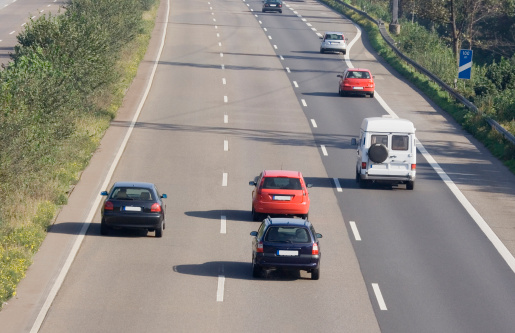

In [5]:
# The notebook orchestration stays hidden; the report renders the real provider pipeline.
experiment.display_case_input("image_structured")
experiment.display_case_code("image_structured")
result = await experiment.run_case("image_structured")
experiment.display_result(result)

## 5. Multi-round tool calling

**Why it matters.** Shows that the `openai` SDK async client can surface tool calls, accept local tool results, and return final structured JSON in a real OpenAI-compatible loop.

**Source.** [`tool_loop_structured_async.py` on GitHub](https://github.com/betabitplus/llm-router/blob/main/experiments/llm_router/exp_0004_openai_compatible/src/tool_loop_structured_async.py) · [browse capsule](https://github.com/betabitplus/llm-router/tree/main/experiments/llm_router/exp_0004_openai_compatible/src)

In [6]:
# The notebook orchestration stays hidden; the report renders the real provider pipeline.
experiment.display_case_input("tool_loop")
experiment.display_case_code("tool_loop")
result = await experiment.run_case("tool_loop")
experiment.display_result(result)

## 6. Named function tool choice

**Why it matters.** Shows that the `openai` SDK can force one named function through `tool_choice` and still return final structured JSON.

**Source.** [`tool_choice_named_structured.py` on GitHub](https://github.com/betabitplus/llm-router/blob/main/experiments/llm_router/exp_0004_openai_compatible/src/tool_choice_named_structured.py) · [browse capsule](https://github.com/betabitplus/llm-router/tree/main/experiments/llm_router/exp_0004_openai_compatible/src)

In [7]:
# The notebook orchestration stays hidden; the report renders the real provider pipeline.
experiment.display_case_input("tool_choice_named")
experiment.display_case_code("tool_choice_named")
result = await experiment.run_case("tool_choice_named")
experiment.display_result(result)

## Conclusion

The captured run exercises the complete OpenAI-compatible experiment surface in one self-contained capsule and records the protocol behavior that informs the adapter boundary.